In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer

import pandas as pd
import numpy as np

# Práctica 7 - Aprendizaje Supervisado

>[Práctica 7 - Aprendizaje Supervisado](#scrollTo=7ufh4aLFD1pb)

>>[Conceptos de aprendizaje supervisado](#scrollTo=AAZt3DY3J7-2)

>>[Carga y partición de dataset](#scrollTo=OfI1Vs4xIeUR)

>>[Puesta en práctica de los conceptos](#scrollTo=1MsUTsawIvmo)

>>>[Introducción](#scrollTo=VYodf8KJIz0r)

>>>[Aplicación de un modelo supervisado y predicción](#scrollTo=D9EV4xPsbzDL)

>>>[Visualización para comparar el dataset original con sus predicciones](#scrollTo=gQKkyrmNb3Rh)

>>>[Conceptos de overfitting y underfitting](#scrollTo=qRsrlun-OPp2)

>>[k-Nearest Neighbors, k-NN (Vecinos más cercanos)](#scrollTo=OnHyn1GgJqWh)

>>>[Ventajas](#scrollTo=OnHyn1GgJqWh)

>>>[Desventajas](#scrollTo=OnHyn1GgJqWh)

>>>[Paso a paso](#scrollTo=s8C5D5lWfHHn)

>>>>[Datos de prueba](#scrollTo=Zza27t6uRxIv)

>>>>[Definición del valor de k](#scrollTo=JOzYOBn1NTDe)

>>>>[Cálculo de distancia](#scrollTo=0FUakHPYUGqF)

>>>>[Complejidad del modelo](#scrollTo=_5PYm1q6VavV)

>>>>[Conclusiones](#scrollTo=tSq4p67uXwgN)

>>[Árboles de decisión](#scrollTo=1YYjwvo7I8RJ)

>>>[Ejemplo inicial](#scrollTo=FXegTO-AKS9o)

>>>[Ventajas](#scrollTo=CG0K-hUVJQ6L)

>>>[Desventajas](#scrollTo=CG0K-hUVJQ6L)

>>>[¿Cómo se contruyen los árboles?](#scrollTo=dRlymXq2ZNzY)

>>>>[Criterios para elegir la mejor división (Paso 3)](#scrollTo=DvgvKscvk6tu)

>>>[Paso a paso](#scrollTo=stpQOcvKe_1x)

>>>>[Creación de datos de prueba](#scrollTo=D1Pqlk7rmqVO)

>>>>[Desarrollo del árbol sin límites (cada nodo tiene pureza total)](#scrollTo=MBhrvmCWmt53)

>>>>[Aplicación de condiciones de parada (pre-prunning)](#scrollTo=4AmtCvHCm8z2)

>>>>[Predicción sobre test](#scrollTo=6HdQpKevnzbt)

>>>[Performance sobre el dataset previo de cancer](#scrollTo=sJu9pPmkbf17)

>>>[Condiciones de parada gráficamente](#scrollTo=eHr9mVjkmbQz)

>>>[Qué pasa con los nulos?](#scrollTo=Rz3pb4ylmk_1)

>>[Métricas de evaluación del modelo](#scrollTo=HmxS6brcJdEW)

>>>[Accuracy](#scrollTo=d5Tmx-G0g8Ze)

>>>[Precisión](#scrollTo=I1yftb23n8cK)

>>>[Sensibilidad (Recall)](#scrollTo=tln7r-TAoA5C)

>>>[F1-Score](#scrollTo=7joy-CdEoDFc)

>>>[Matriz de Confusión](#scrollTo=34K7KKNYoE9A)

>>>>[Ejemplo con el dataset de cancer](#scrollTo=ImFVpiY9hJCi)

>>>[Ejemplo multiclase](#scrollTo=g3pUwACnahaj)

>>[Bibliografía](#scrollTo=LmlxWP8zeeV3)



## Conceptos de aprendizaje supervisado


---



**Objetivo:** predecir una salida dado un cierto input y con una precisión adecuada.


---


**Variantes**



*   Clasificación: se predice el valor que toma una **clase** o **categoría**. Hay un valor acotado de posibilidades. Se dice que el problema es de clasificación binaria (dos clases) o multiclase (múltiples clases).
*   Regresión: se predice una número continuo.


**Ejemplos de lo visto en clases anteriores**

- Predicción del precio de propiedades (regresión)
- Predicción de la calidad de vino (clasificación)

## Carga y partición de dataset

El propósito de esto es construir un modelo que pueda hacer predicciones con cierto grado de certeza en data que nunca vio. Por ello, cualquier dataset sobre el cual quiera aplicarse un modelo debe particionarse en dos partes:


1.   Entrenamiento (**train**)
2.   Test

El split de ambos se hace de forma tal que el modelo pueda aprender sobre la clase que nos interesa predecir en el **set de entrenamiento**. Dicho algoritmo se pondrá a prueba en el **set de test**, donde se conoce el valor que toma la variable que nos interesa predecir. De esa forma, podemos obtener los valores predichos sobre instancias del dataset que **no fueron usadas para entrenar el modelo.**

Dicho de otra forma, estamos poniendo a prueba al modelo a fines de cuantificar a través de métricas que veremos más adelante que tan bien hizo esas predicciones.

El porcentaje usual de split es 80/20.



## Puesta en práctica de los conceptos

### Introducción

Cargaremos un dataset llamado `iris` que tiene las siguientes variables:



*   `sepal length (cm)`
*   `sepal width (cm)`
*   `petal length (cm)`
*   `petal width (cm)`

La variable objetivo que nos interesará predecir es la especie, que toma alguno de los siguientes valores:

* `setosa`
* `versicolor`
* `virginica`








In [ ]:
# @title
# Carga del dataset
iris = datasets.load_iris()
# Definimos las variables y la target
X = iris.data
y = iris.target
target_nombres = iris.target_names
#Lo convierto en dataframe
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = y


Quedan definidas las variables numéricas X y el vector de la variable target (especie) que queda mapeado a valores

In [ ]:
# @title
print(X)
print(y)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

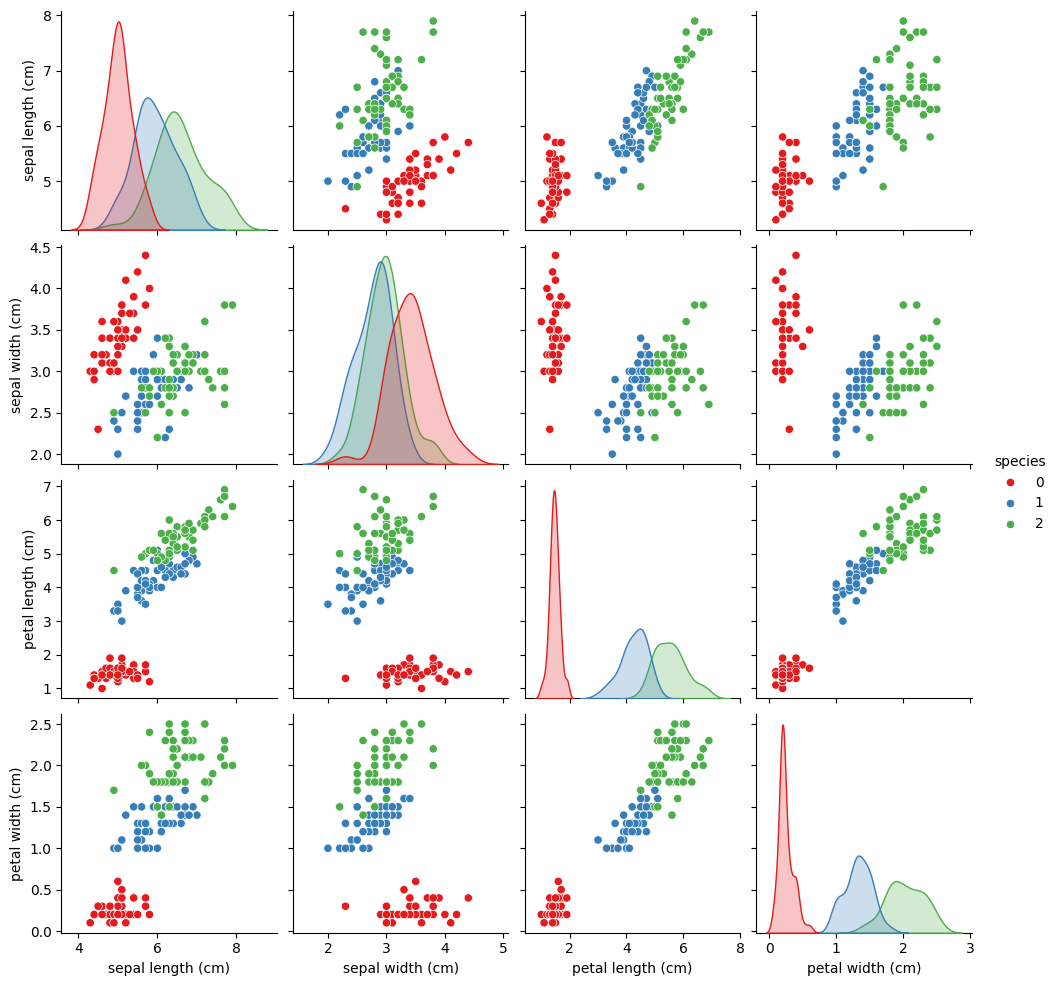

In [ ]:
# @title
# Graficamos un pair plot coloreando por nuestra variable target
sns.pairplot(iris_df, hue='species', palette='Set1')
plt.show()


Apliquemos un modelo que busque predecir la clase. Haremos lo siguiente:



1.   Dividir dataset en train-test
2.   Aplicar modelo al train
3.   Predecir sobre test
4.   Ver visualmente como estuvo el modelo. Más adelante veremos métricas, que es la forma de cuantificar la performance de un modelo.



### Aplicación de un modelo supervisado y predicción

In [ ]:
#Divido el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44)

# Entreno un modelo de aprendizaje supervisado
knn = KNeighborsClassifier(n_neighbors=4)  # No interesa entender esto en este punto de la clase
knn.fit(X_train, y_train)

# Hago la predicción del modelo sobre la partición de test
y_pred = knn.predict(X_test)

# Creo dataframe con el test
df_test = pd.DataFrame(X_test, columns=iris.feature_names)
df_test['species'] = y_test
df_test['predicted'] = y_pred
df_test['pred'] = True  # Para indicar que corresponde a la predicción

# Creo dataframe con el train
df_train = pd.DataFrame(X_train, columns=iris.feature_names)
df_train['species'] = y_train
df_train['pred'] = False  # Para indicar que NO corresponde a la predicción

# Combino ambos dataframes para llegar a una nueva variante del original
df_iris_prediccion = pd.concat([df_train, df_test], ignore_index=True)


### Visualización para comparar el dataset original con sus predicciones

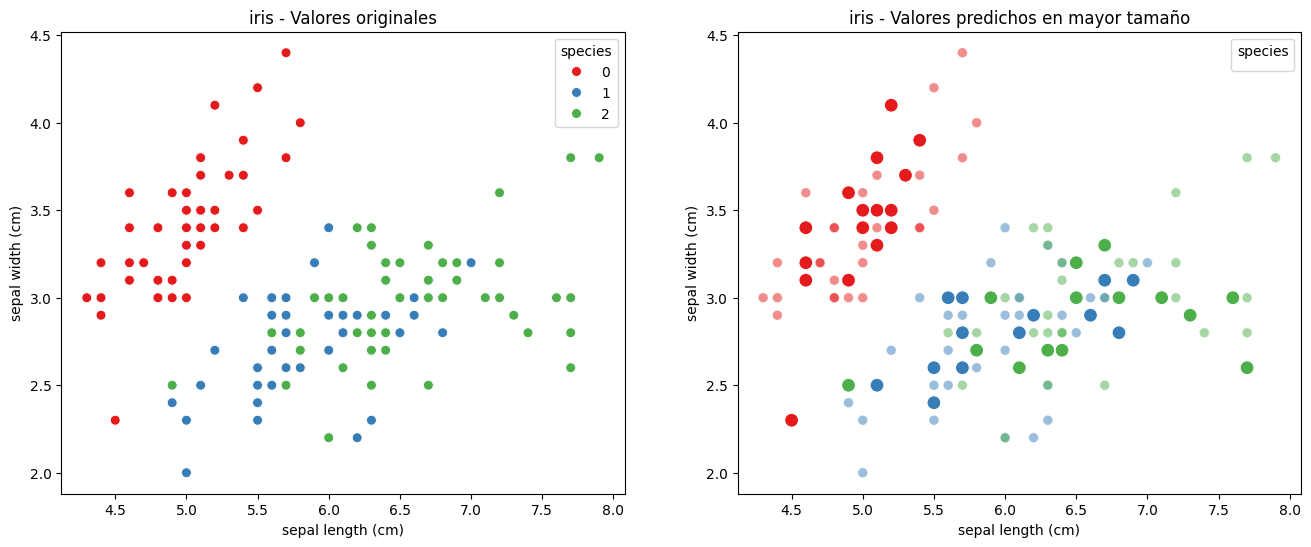

<Figure size 800x800 with 0 Axes>

In [ ]:

#Función para graficar con doble condicion
def scatter_plot_con_transparencia(df, x_col, y_col, color_col, alpha_col, alpha_pred=1.0, alpha_no_pred=0.5,ax=None):
    """
    Parámetros:
    - df: dataframe
    - x_col: Eje X.
    - y_col: Eje Y.
    - color_col: Color de puntos
    - alpha_col: Transparencia (Booleano).
    - alpha_pred: donde True.
    - alpha_no_pred: donde False.
    """

    # Separo por alpha
    df_pred = df[df[alpha_col] == True]
    df_non_pred = df[df[alpha_col] == False]

    # Scatter
    plt.figure(figsize=(8, 8))

    # Grafico de puntos train
    sns.scatterplot(data=df_non_pred, x=x_col, y=y_col, hue=color_col, palette='Set1',s=50 ,alpha=alpha_no_pred, legend=False,ax=ax)

    # Grafico de predicción
    sns.scatterplot(data=df_pred, x=x_col, y=y_col, hue=color_col, palette='Set1',s=100, alpha=alpha_pred, legend=False,ax=ax)

    # Leyenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title=color_col)

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Dataset original
sns.scatterplot(data=iris_df, x='sepal length (cm)', y='sepal width (cm)', hue='species', palette='Set1',s=50, ax=ax[0])
ax[0].set_title('iris - Valores originales')

# Dataset con predicciones
scatter_plot_con_transparencia(df_iris_prediccion, 'sepal length (cm)', 'sepal width (cm)', 'species', 'pred', ax=ax[1])
ax[1].set_title('iris - Valores predichos en mayor tamaño')

plt.show()


Comparando ambos gráficos se observa como ciertos puntos de mayor tamaño se corresponden con el mismo color (predicciones correctas), mientras que en otros casos cambia el color respecto al valor original (predicción incorrecta)

### Conceptos de overfitting y underfitting

De lo visto se desprende que lo que buscamos es un modelo que pueda generalizar bien del training al test, con la mayor precisión posible.

Si ambos sets se componen de una población de similares características, esperamos ver un desempeño similar. Sin embargo, esto no ocurre siempre.

Se puede complejizar un modelo tanto como uno quiera sobre el training set. A esto se llama ***Overfitting***. En otras palabras, se trata de construir un modelo que se adapte a todas las particularidades del set de entrenamiento pero no es capaz de generalizar en data que nunca vio.

De manera contraria, si no se captura la suficiente variabilidad de los datos de entrenamiento tendremos un modelo extremadamente simple (***Underfitting***)

Tenemos que hacer un trade-off, donde en función de lo que resignemos que el modelo aprenda del set de entrenamiento mejoraremos su performance para datos no vistos



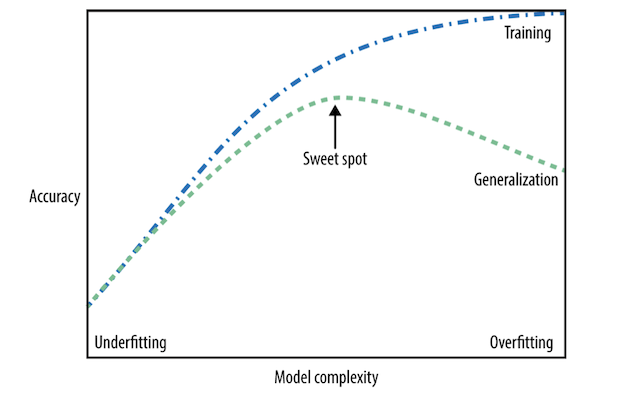


## k-Nearest Neighbors, k-NN (Vecinos más cercanos)



*  **Objetivo:** predecir la etiqueta o valor de una muestra nueva basándose en la similitud con otras muestras en el conjunto de datos de entrenamiento.
*   Utilizable en regresión y clasificación.


---


### **Ventajas**
- Simplicidad: Es fácil de entender e implementar.
- Flexibilidad: Puede utilizarse tanto para clasificación como para regresión.
- Sin Suposiciones Previas: No hace suposiciones sobre la distribución de los datos.

### **Desventajas**
- Costo Computacional: El cálculo de distancias para todas las muestras puede ser costoso en términos de tiempo y recursos, especialmente para conjuntos de datos grandes.
- Eficiencia con Datos Desbalanceados: k-NN puede ser sensible a conjuntos de datos con clases desbalanceadas.
- Almacenamiento: Requiere almacenar todo el conjunto de datos de entrenamiento, lo que puede ser problemático para conjuntos de datos grandes.


---









### Paso a paso

#### Datos de prueba

Usaremos un dataset de cancer, que tiene variable de maligno,benigno para tumores. Nos interesará predecir el valor de esa clase.

In [ ]:
# Load the cancer dataset
cancer = load_breast_cancer()

# Variables
print("Variables:", cancer.feature_names)

# Target
print("Target:", cancer.target_names)

# Convierto a dataframe to DataFrame
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target


X = cancer.data
y = cancer.target


Variables: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target: ['malignant' 'benign']


In [ ]:
data.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
307,9.00,14.40,56.36,246.3,0.07005,0.03116,0.003681,0.003472,0.1788,0.06833,...,20.07,60.90,285.5,0.09861,0.05232,0.01472,0.01389,0.2991,0.07804,1
191,12.77,21.41,82.02,507.4,0.08749,0.06601,0.031120,0.028640,0.1694,0.06287,...,23.50,89.04,579.5,0.09388,0.08978,0.05186,0.04773,0.2179,0.06871,1
354,11.14,14.07,71.24,384.6,0.07274,0.06064,0.045050,0.014710,0.1690,0.06083,...,15.82,79.62,453.5,0.08864,0.12560,0.12010,0.03922,0.2576,0.07018,1
562,15.22,30.62,103.40,716.9,0.10480,0.20870,0.255000,0.094290,0.2128,0.07152,...,42.79,128.70,915.0,0.14170,0.79170,1.17000,0.23560,0.4089,0.14090,0
550,10.86,21.48,68.51,360.5,0.07431,0.04227,0.000000,0.000000,0.1661,0.05948,...,24.77,74.08,412.3,0.10010,0.07348,0.00000,0.00000,0.2458,0.06592,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### Definición del valor de k

Se definen cuántos vecinos va a ver el modelo para hacer una predicción. La clase de mayor popularidad será la elegida. En este caso la elección es binaria

Si fuese regresión se tomaría el promedio de los valores de los vecinos encontrados

In [ ]:
len(X_train)

105

In [ ]:
#Divido el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entreno un modelo de aprendizaje supervisado
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Hago la predicción del modelo sobre la partición de test
y_pred = knn.predict(X_test)

print('Precisión sobre training: {:2.2f}'.format(knn.score(X_train,y_train)))
print('Precisión sobre test: {:2.2f}'.format(knn.score(X_test,y_test)))

Precisión sobre training: 1.00
Precisión sobre test: 0.93


#### Cálculo de distancia

Con el parámetro metric podemos ajustar como el método computa las distancias de cada punto a todo el resto.

Por defecto se utiliza la distancia de Minkowski, que es una generalización de la distancia euclidiana.

#### Complejidad del modelo

Un modelo con bajo "k" lleva a un modelo de alta complejidad donde solo clasificará por lo más cercano que ve.
Un modelo con alto "k" llevará a mayor generalización, aunque hay que tener precaución de que no esté viendo todas las instancias por ejemplo

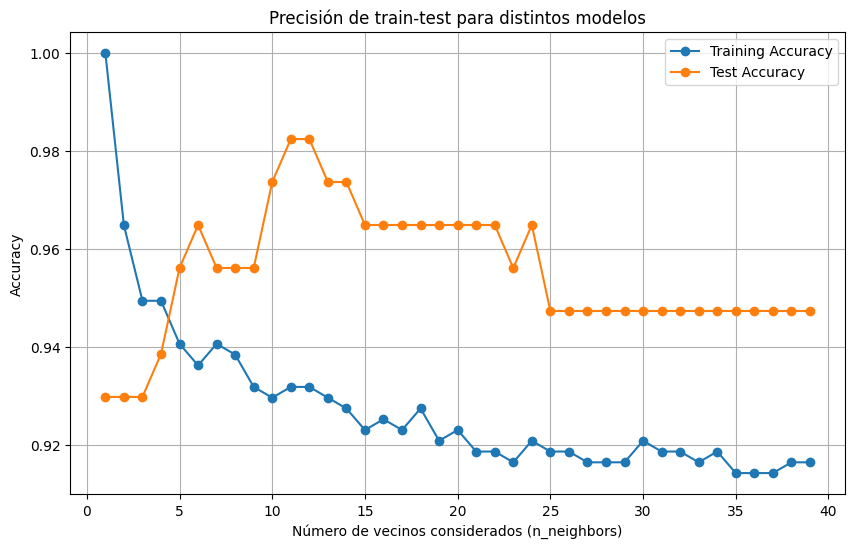

In [ ]:
# Métrica de precisión
train_accuracies = []
test_accuracies = []

# Rango de vecinos a probar
n_neighbors_rango = range(1, 40)

# Entreno un modelo para cada K
for n_neighbors in n_neighbors_rango:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Calculo métricas
    train_accuracies.append(knn.score(X_train, y_train))
    test_accuracies.append(knn.score(X_test, y_test))

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_rango, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(n_neighbors_rango, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Número de vecinos considerados (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Precisión de train-test para distintos modelos')
plt.legend()
plt.grid(True)
plt.show()

#### Conclusiones

- Predicción lenta con alta dimensionalidad
- Mala performance con datasets donde la mayoría de las features son 0 en todo sun rango
- Buen approach inicial para entender un problema y pasar a modelos más completos

## **Árboles de decisión**


*  **Objetivo:** crear un modelo predictivo que pueda tomar decisiones basadas en una secuencia de reglas lógicas simples inferidas de los datos. Secuencias de if/else.
* **Concepto**: Segmentar el espacio de variables predictoras $X_i$ en varias regiones simples. Para hacer una predicción para una observación dada, se utiliza típicamente la media (para regresión) o la moda (para clasificación) de los valores de respuesta $Y$ de las observaciones de entrenamiento que caen dentro de la región a la que pertenece la nueva observación.
* Se llaman así porque las reglas de división que segmentan el espacio de variables predictoras pueden resumirse en una estructura de árbol.
* Asimilable a un juego tipo "Quién es quién?". Nos interesa llegar al resultado correcto con la menor cantidad de preguntas posible.



---
### **Ejemplo inicial**

Usamos un conjunto de datos de bateadores para predecir el salario de un jugador de baseball en función de los años (la cantidad de años que jugó en las ligas mayores) y los hits (la cantidad de hits que realizó en el año anterior). El salario (en miles de USD) fue transformado logarítmicamente para que su distribución tenga una forma de campana más típica.
En la figura de la izquierda vemos el esquema del árbol de decisión. Tiene dos nodos internos y tres nodos terminales (hojas).
En la figura de la derecha vemos las tres regiones en que queda divido el espacio de variables predictoras (en este caso 2D).

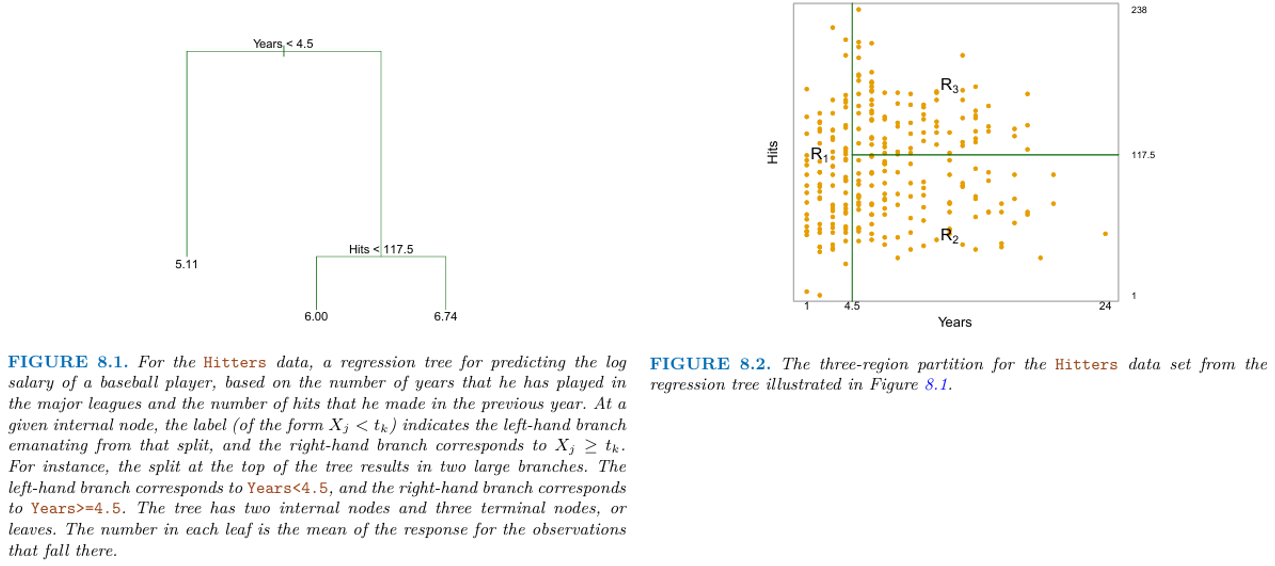


---
### **Ventajas**
- Interpretabilidad: Los árboles de decisión son fáciles de entender e interpretar visualmente.
- No Requiere Normalización de Datos: No es necesario normalizar o estandarizar los datos antes de aplicar el algoritmo.
- Manejo de Características Mixtas: Puede manejar tanto características numéricas como categóricas sin necesidad de preprocesamiento adicional.


### **Desventajas**
- Sensibilidad al Ruido y Datos Atípicos: Los árboles de decisión pueden ser sensibles al ruido y los datos atípicos, lo que puede conducir a un sobreajuste.
- Propensión al Sobreajuste: Los árboles de decisión tienden a crear modelos complejos que pueden sobreajustar los datos de entrenamiento.
- Inestabilidad: Pequeños cambios en los datos de entrenamiento pueden resultar en cambios significativos en la estructura del árbol.



---


### **¿Cómo se contruyen los árboles?**
La mayoría de los algoritmos de árboles definen la estructura del árbol a partir de la **división binaria recursiva**.

En cada paso (en cada nodo) del proceso de construcción del árbol, el algoritmo realiza lo siguiente:
1. Considera todas las variables predictoras disponibles.
2. Considera todos los posibles puntos de corte (umbrales) para cada una de esas variables.
3. Para cada posible división (cada combinación de variable y punto de corte), evalúa qué tan bien esa división particular segmenta los datos según un criterio específico.
4. La división (compuesta por una variable y su punto de corte) que resulta en la mayor mejora según el criterio seleccionado es elegida para formar el nodo actual.
5. Se repite el proceso recursivamente en los nodos hijos, hasta alcanzar una condición de parada.

#### **Criterios para elegir la mejor división (Paso 3)**

Los criterios que se utilizan para evaluar la calidad de una división dependen de si se está construyendo un árbol de regresión o un árbol de clasificación. Dentro de los criterios más comunes tenemos:
  * **Clasificación: Impureza de Gini**

  $$
    G_i = 1 - \sum^{n}_{k=1}p_{i,k}^2
  $$

    donde
    - $G_i$ es la impureza de Gini del nodo $i$

    - $p_{i,k}$ es la proporción de instancias de la clase $k$ entre las instancias de entrenamiento del nodo $i$.

    La función a minimizar es:

    $$
    J(k,t_k) = \frac{m_{izq}}{m}G_{izq}+\frac{m_{der}}{m}G_{der}
    $$

    donde
    * $m_{izq/der}$ es el número de instancias del subconjunto izquierda/derecha.

\
  * **Regresión: Error cuadrático medio (ECM o MSE)**
$$
ECM_{nodo} = \frac{\sum_{i\in nodo}(\hat{y}_{nodo}-y^{(i)})^2}{m_{nodo}}
$$
    donde:
    * $\hat{y}_{nodo}$ es el valor promedio de $y$ de todas las instancias del nodo

    La función a minimizar es:
    $$
    J(k,t_k) = \frac{m_{izq}}{m}ECM_{izq}+\frac{m_{der}}{m}ECM_{der}
    $$

### Paso a paso

#### Creación de datos de prueba

In [ ]:
from sklearn.datasets import make_moons
from sklearn import tree
X, y = make_moons(n_samples=200, noise=0.20, random_state=42)
print(X.shape)
print(y.shape)
print(X[0:10])
print(y[0:10])


(200, 2)
(200,)
[[-1.10689665e+00  4.22928095e-02]
 [ 9.56799641e-01  4.56750492e-01]
 [ 7.33516277e-01  5.84617437e-01]
 [ 1.11140659e+00 -3.09213987e-01]
 [ 2.09081764e-01  6.56679495e-04]
 [ 3.92205613e-01  3.20238629e-01]
 [-7.56185073e-01  8.29954942e-01]
 [ 1.50692319e+00 -1.11129319e-01]
 [ 2.04279588e+00 -3.79762883e-02]
 [ 1.44143707e-01  9.16713583e-01]]
[0 0 0 1 1 1 0 1 1 0]


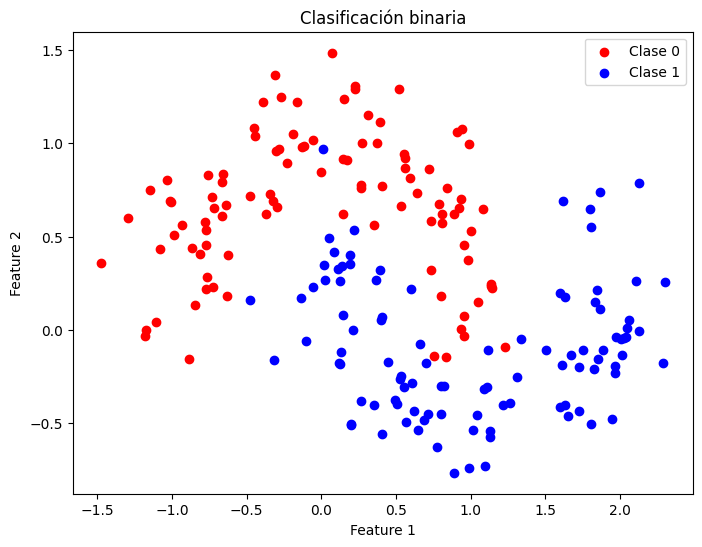

In [ ]:
# Ploteo
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plt.title('Clasificación binaria')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

#### Desarrollo del árbol sin límites (cada nodo tiene pureza total)

1. Comienza con el conjunto de datos completo y selecciona la característica (atributo) que mejor separa los datos en función de alguna medida de pureza (como la *information gain* o la impureza de Gini).
2. Este nodo representa la pregunta inicial que se utilizará para dividir los datos en subconjuntos más pequeños.
3. Se repite el proceso de selección de características y creación de nodos para cada subconjunto de datos resultante.
Este proceso continúa recursivamente.

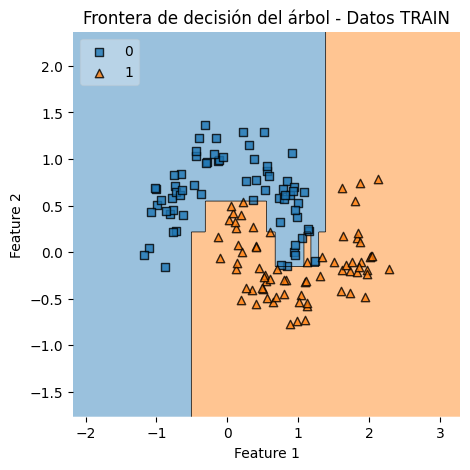

In [ ]:
#Divido el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Aplicación del modelo
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

#Visualización de fronteras de decisión
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(5,5))
plot_decision_regions(X_train, y_train, clf=clf, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Frontera de decisión del árbol - Datos TRAIN')
plt.show()


Vamos a visualizar los test que hace el árbol, siguiendo las fronteras gráficas. Notar que la pureza en las hojas finales del árbol es del 100%

In [ ]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("clasificacion_binaria")

'clasificacion_binaria.pdf'

#### Aplicación de condiciones de parada (pre-prunning)

Condiciones:
- Profundidad máxima predefinida (`max_depth`)
- Un número mínimo de muestras en los nodos (`min_samples_leaf`)
- Número de hojas finales que tendrá el árbol preimpuestas (`max_leaf_nodes`)





In [ ]:
# Aplicación del modelo
clf_podado = tree.DecisionTreeClassifier(max_depth = 3)
clf_podado = clf_podado.fit(X_train, y_train)

Después de que el árbol se haya construido por completo, se puede aplicar un proceso de poda para reducir su tamaño y mejorar su generalización.
El podado implica eliminar ciertas partes del árbol que no son significativas o pueden causar overfitting. (post-prunning)

#### Predicción sobre test

Para una nueva instancia, se sigue el camino desde la raíz hasta una hoja del árbol basándose en los valores de sus características.
La predicción se realiza asignando la clase mayoritaria (en clasificación) o calculando el promedio (en regresión) de las muestras en esa hoja.

In [ ]:
from sklearn.metrics import accuracy_score

# Predicción con cada uno de los modelos
y_pred_completo = clf.predict(X_test)
y_pred_podado = clf_podado.predict(X_test)

# Calculo métrica de
accuracy_completo = accuracy_score(y_test, y_pred_completo)
accuracy_podado = accuracy_score(y_test, y_pred_podado)
print(f"Accuracy para árbol completo:", "{:.2f}".format(accuracy_completo))
print(f"Accuracy para árbol podado:",  "{:.2f}".format(accuracy_podado))

Accuracy para árbol completo: 0.98
Accuracy para árbol podado: 0.88


Vemos que el árbol completo da mejores resultados que el árbol podado. En las siguientes figuras podemos ver por qué en este ejemplo resulta mejor no podar (o no podar tanto).

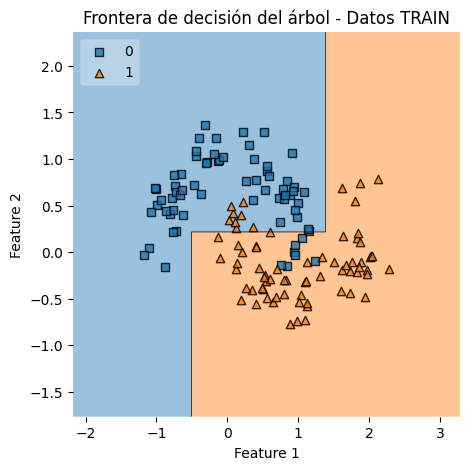

In [ ]:
#Visualización de fronteras de decisión
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(5,5))
plot_decision_regions(X_train, y_train, clf=clf_podado, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Frontera de decisión del árbol - Datos TRAIN')
plt.show()

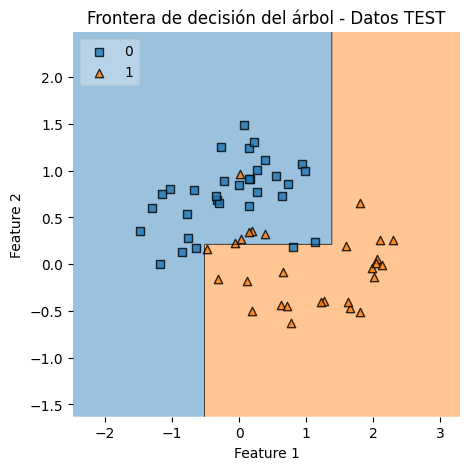

In [ ]:
plt.figure(figsize=(5,5))
plot_decision_regions(X_test, y_test, clf=clf_podado, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Frontera de decisión del árbol - Datos TEST')
plt.show()

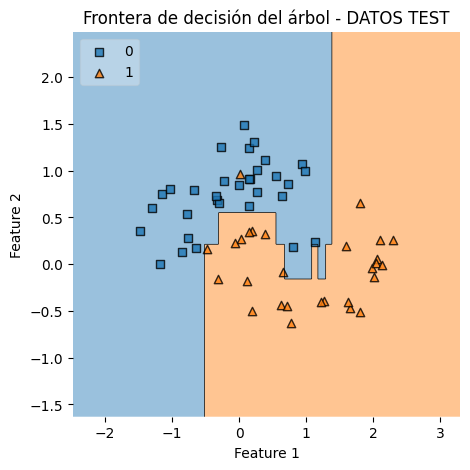

In [ ]:
plt.figure(figsize=(5,5))
plot_decision_regions(X_test, y_test, clf=clf, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Frontera de decisión del árbol - DATOS TEST')
plt.show()

### Performance sobre el dataset previo de cancer

In [ ]:
X = cancer.data
y = cancer.target
#Divido el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


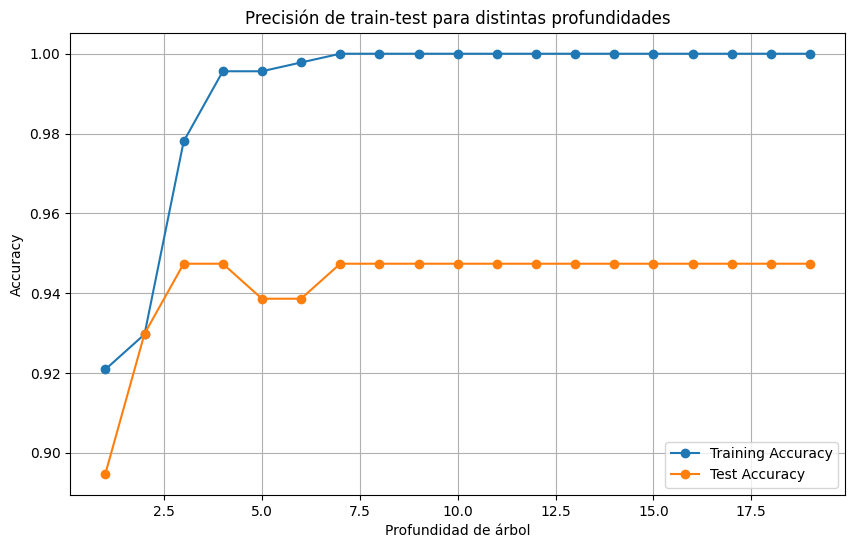

In [ ]:
# Métrica de precisión
train_accuracies = []
test_accuracies = []

# Rango de profundidades a probar
max_depth_rango = range(1, 20)

# Entreno un modelo para cada K
for profundidad in max_depth_rango:
    clf = tree.DecisionTreeClassifier(max_depth = profundidad,random_state=28)
    clf = clf.fit(X_train, y_train)
    # Hago predicciones
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Calculo métricas
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))



# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(max_depth_rango, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(max_depth_rango, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Profundidad de árbol')
plt.ylabel('Accuracy')
plt.title('Precisión de train-test para distintas profundidades')
plt.legend()
plt.grid(True)
plt.show()

### Condiciones de parada gráficamente

**Max_depth gráficamente**


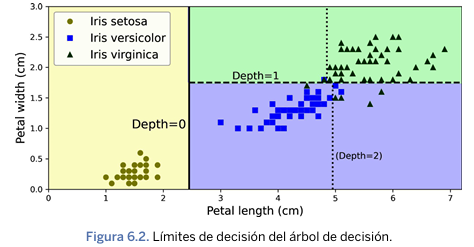

**Min_samples_leaf gráficamente**

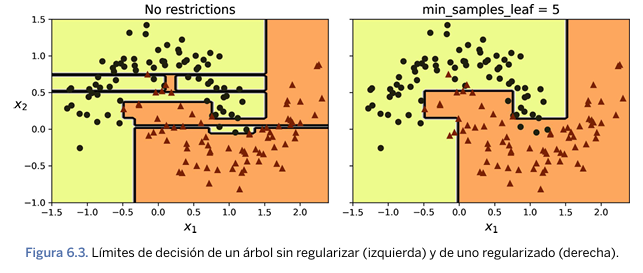

Fuente: Géron, A. (2020). *Aprende machine learning con scikit-learn, keras y tensorflow. Conceptos, herramientas y técnicas para conseguir sistemas inteligentes.*

### Qué pasa con los nulos?

Se debe hacer un preprocesamiento con este tipo de modelos, ya que no procesa valores nulos este tipo de modelos. Versiones más complejas tales como XGBoost sí los soportan en los sets de entrenamiento

## Métricas de evaluación del modelo

Hasta ahora hemos presentado el accuracy de los modelos (qué tantas predicciones correctas hace el modelo por sobre el total). Sin embargo, se pueden distinguir varios tipos de métricas relevantes.



### Accuracy

La *accuracy* es una medida de la proporción de predicciones correctas realizadas por el modelo sobre el total de predicciones. Se calcula de la siguiente manera:


\begin{align}
\text{Accuracy} = \frac{\text{Número de predicciones correctas}}{\text{Número total de predicciones}}
\end{align}




### Precisión

La precisión es la proporción de instancias predichas como positivas que son verdaderamente positivas. Se calcula de la siguiente manera:

\begin{align}
\text{Precision} = \frac{\text{Verdaderos positivos}}{\text{Verdaderos positivos} + \text{Falsos positivos}}
\end{align}

En el filtrado de spam, es crucial maximizar la precisión para evitar que correos legítimos sean clasificados incorrectamente como spam. Es preferible tener menos falsos positivos (correos legítimos clasificados como spam) aunque esto pueda significar perder algunos correos de spam.



### Sensibilidad (Recall)

La sensibilidad es la proporción de instancias verdaderamente positivas que fueron identificadas correctamente por el modelo. Se calcula de la siguiente manera:

\begin{align}
\text{Recall} = \frac{\text{Verdaderos positivos}}{\text{Verdaderos positivos} + \text{Falsos negativos}}
\end{align}


En el diagnóstico de cáncer, el recall es relevante para garantizar que ningún caso positivo (cáncer) sea pasado por alto. Es preferible tener más falsos positivos (pacientes sanos diagnosticados incorrectamente como enfermos) que falsos negativos (pacientes enfermos no diagnosticados).

### F1-Score

El F1-Score es una medida que combina la precisión y la sensibilidad en un solo número. Se calcula de la siguiente manera:

\begin{align}
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
\end{align}



### Matriz de Confusión

La matriz de confusión es una tabla que muestra el número de predicciones correctas e incorrectas para cada clase. Proporciona información detallada sobre el rendimiento del modelo.

Es una matriz de NxN donde N es el número de clases.

Por definición una matriz de confusión $C$ es aqulla donde cada elemento $C_{i,j}$ es igual al número de observaciones pertenecientes a la clase $i$ y predichas en la clase $j$.

#### Ejemplo con el dataset de cancer

In [8]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

#Divido el dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Entreno con una profundidad
clf = tree.DecisionTreeClassifier(max_depth = 6,random_state=42)
clf = clf.fit(X_train, y_train)
# Hago predicciones
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [9]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
conf_matrix = confusion_matrix(y_test, y_pred)


# Imprimir métricas
print("Accuracy:{:.3f}".format(accuracy))
print("Precision:{:.3f}".format(precision))
print("Recall:{:.3f}".format(recall))
print("F1 Score::{:.3f}".format(f1))
sns.heatmap(conf_matrix,annot=True,fmt='g',cmap='Blues',cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('VALOR PREDICHO')
plt.ylabel('VALOR REAL')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

### Ejemplo multiclase

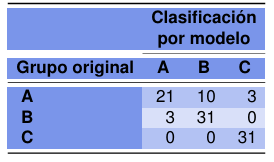

## Bibliografía

Libros

- Géron, A. (2020). *Aprende machine learning con scikit-learn, keras y tensorflow. Conceptos, herramientas y técnicas para conseguir sistemas inteligentes.*
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning with applications in Python.* Disponible en https://www.statlearning.com/


Documentación de módulos

- [NumPy](https://numpy.org/doc/1.26/)

- [Pandas](https://pandas.pydata.org/docs/)

- [Seaborn](https://seaborn.pydata.org/)

- [Scikit-Learn](https://scikit-learn.org/stable/)